# (1+1)D Viscous Burgers Equation with Physics-Informed Neural Networks

This notebook demonstrates how to solve the **viscous Burgers equation** using Physics-Informed Neural Networks (PINNs). The viscous Burgers equation is:

$$\partial_t u + \partial_x \left( \frac{1}{2} u^2 - \nu \partial_x u \right) = 0, \quad \text{for } (t, x) \in [0, 1] \times [-1, 1]$$

which can be written in convective form as:

$$\partial_t u + u \partial_x u - \nu \partial_{xx} u = 0$$

with initial condition:
$$u(0, x) = -\sin(\pi x), \quad \text{for } x \in [-1, 1]$$

and boundary conditions:
$$u(t, -1) = u(t, 1) = 0, \quad \text{for } t \in [0, 1]$$

where:
- $\nu = 0.01/\pi$ is the viscosity coefficient

We will solve this problem using:
1. **Standard PINN**: A single neural network trained on the entire domain
2. **FB-PINN + Temporal Curriculum**: 4×4 domain decomposition with progressive time-window expansion


In [1]:
import pinns

import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

# Reference Solution (pseudo-spectral adaptive Dopri5)

A high-accuracy reference is computed using `ModelSpectralSolver` + `IntegratorDopri5`
(native adaptive Dormand-Prince 4(5)) on a **DST-1 spectral grid** with homogeneous Dirichlet BCs.

$$\partial_t \hat{u}_k = \underbrace{-\nu k^2 \hat{u}_k}_{\text{linear (exact)}} + \underbrace{\widehat{(-u \partial_x u)}}_{\text{nonlinear (physical-space FD)}}$$

`bc="dirichlet"` uses the Discrete Sine Transform — interior nodes only, zero BCs
at $x = \pm 1$ are implicit in the basis.  The nonlinear term $-u \partial_x u$ is
evaluated in physical space using second-order central differences (matching the
previous `scipy` approach), then transformed back to spectral space.


Text(0.5, 1.0, 'Reference solution u(t,x)')

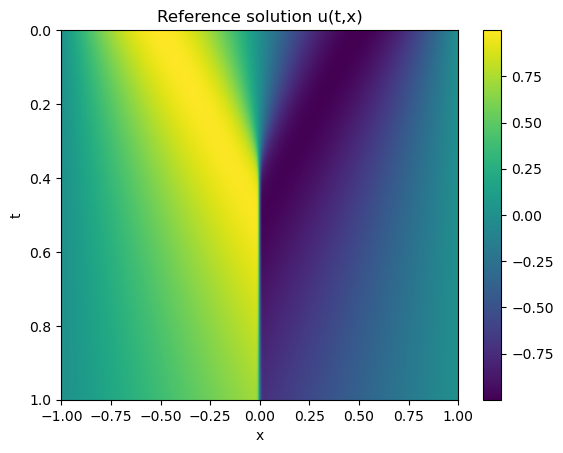

In [2]:
# ── Parameters ────────────────────────────────────────────────────────────────
Nx  = 512   # interior grid points
Nt  = 200
nu = 0.01 / np.pi

# ── DomainCubic + ModelSpectralSolver ─────────────────────────────────────────
domain_grid = pinns.DomainCubic(
    space=[(-1.0, 1.0)],
    time=(0.0, 1.0),
)

integrator_ref = pinns.AdaptiveIntegrator(
    pinns.IntegratorDopri5(),
    dt0=1e-2,
    max_steps=2**17,
)

model_burgers = pinns.ModelSpectralSolver(domain_grid, ["u"], integrator_ref, shape=(Nx,))

# Grid nodes are exposed by ModelSpectralSolver after construction
x_ref = np.array(model_burgers.x)   # (Nx,) interior nodes
dx    = float(x_ref[1] - x_ref[0])

# ── Linear operator: ν ∂²_x  →  −ν k² in spectral space ─────────────────────
model_burgers.set_linear_op(
    lambda X, p: {"u": -p["parameter"]["nu"] * X**2}
)

# ── Nonlinear operator: −u ∂_x u (central FD in physical space) ──────────────
def burgers_nonlinear(X, U, p):
    u     = model_burgers.inverse(U["u"])                       # (Nx,) interior
    u_ext = jnp.concatenate([jnp.zeros(1), u, jnp.zeros(1)])   # ghost BCs
    u_x   = (u_ext[2:] - u_ext[:-2]) / (2.0 * dx)             # central diff ∂_x u
    return {"u": model_burgers.forward(-u * u_x)}

model_burgers.set_source_fn(burgers_nonlinear)
model_burgers.add_parameter("nu", nu)

# ── Initial condition: u(x, 0) = −sin(πx) ────────────────────────────────────
model_burgers.add_initial(-jnp.sin(jnp.pi * jnp.array(x_ref)))

# ── Forward solve — runs once, caches interpolants ────────────────────────────
U_sol = model_burgers.solve()

# ── Reference callable: predict(X) interpolates without re-solving ────────────
X = np.linspace(-1, 1, Nx)
T = np.linspace(0, 1, Nt)
X, T = np.meshgrid(X, T)
X = np.stack([X.flatten(), T.flatten()], axis=-1)  # (Nx*Nt, 2)
u_reference = model_burgers.predict(X)   # function, not array

# ── Quick plot ────────────────────────────────────────────────────────────────
plt.imshow(u_reference.reshape(Nt, Nx), extent=(-1, 1, 1, 0), aspect='auto', cmap='viridis')
plt.colorbar(); plt.xlabel("x"); plt.ylabel("t"); plt.title("Reference solution u(t,x)")

# Create dataset

In [3]:
N_data = 1000

x = np.random.uniform(-1, 1, (N_data, 1))  # (1000, 1) random x in [-1, 1]
t = np.random.uniform(0, 1, (N_data, 1))

X_data = np.hstack([x, t])  # (1000, 2) pairs of (x, t)
U_data = model_burgers.predict(X_data) + np.random.normal(0, 0.01, (N_data, 1))  # Add noise to data

dataset = pinns.Dataset()

dataset.add_points(X_data, U_data, "data")

Dataset(1 term(s)){
  'data': 1000 pts, comp=[0]
}

# Define the Problem

In this section, we set up all the components needed to define our PINN problem:
1. Physical parameters (viscosity)
2. The differential equation (residual form)
3. The computational domain
4. Initial and boundary conditions

## Domain of the Problem

We define the (1+1)D space-time domain $\Omega = [0, 1] \times [-1, 1]$ for $(t, x)$.

In [4]:
domain = pinns.DomainCubic(
    space=[(-1, 1)],  # x_min, x_max
    time=[0, 1],   # t_min, t_max
)

## Differential Equation

### The PDE Residual
The `burgers_residual` function computes the residual of the viscous Burgers equation. For PINNs, we train the network to minimize this residual:

$$\mathcal{R} = \partial_t u + u \partial_x u - \nu \partial_{xx} u = 0$$

where we are going to start from a $\nu_0 = 1/\pi$ as the viscosity coefficient.

In [5]:
nu0 = 1 / np.pi

problem = pinns.ProblemStrong(
    domain,
    output_names=["u"]
)

problem.add_parameter('nu', nu0)

ProblemStrong(domain=DomainCubic, n_dims=2, n_outputs=1, inner=0, boundary=0, initial=0, params=['nu'], trainable=[])

In [6]:
# Column convention
def burgers_residual(X, U, params, derivative=None):
    # Get viscosity from params (avoids JAX closure issues)
    nu = params["parameter"]['nu']
    
    # Compute derivatives
    u_t = derivative(U, X, 0, (1,))     # ∂u/∂t
    u_x = derivative(U, X, 0, (0,))     # ∂u/∂x
    u_xx = derivative(U, X, 0, (0, 0))  # ∂²u/∂x²
    
    # Viscous Burgers residual: ∂u/∂t + u·∂u/∂x - ν·∂²u/∂x² = 0
    res = u_t + U * u_x - nu * u_xx

    return res

problem.add_inner(
    burgers_residual
)

ProblemStrong(domain=DomainCubic, n_dims=2, n_outputs=1, inner=1, boundary=0, initial=0, params=['nu'], trainable=[])

## Initial and Boundary Conditions

For the viscous Burgers problem, we have:

**Initial condition** at $t = 0$:
$$u(0, x) = -\sin(\pi x), \quad \text{for } x \in [-1, 1]$$

**Boundary conditions** (homogeneous Dirichlet):
$$u(t, -1) = 0 \quad \text{and} \quad u(t, 1) = 0, \quad \text{for } t \in [0, 1]$$

In [7]:
import jax.numpy as jnp

# Initial condition: u(0, x) = -sin(πx)
def initial_condition(X):
    x = X[:, 0:1]  # First column is x
    return -jnp.sin(jnp.pi * x)

problem.add_initial(
    initial_condition,
    name="initial",
)

# Boundary conditions: u(t, -1) = 0 and u(t, 1) = 0
problem.add_boundary(
    0.0,
    region="xmin",
    name="xmin",
)
problem.add_boundary(
    0.0,
    region="xmax",
    name="xmax",
)


ProblemStrong(domain=DomainCubic, n_dims=2, n_outputs=1, inner=1, boundary=2, initial=1, params=['nu'], trainable=[])

# Solve with Standard PINN

## Network Architecture

We use a **Fully Connected Neural Network (FNN)** with:
- **Architecture**: [2, 256, 256, 1] - 2 inputs (t, x), two hidden layers with 256 neurons each, 1 output (u)
- **Activation**: `tanh` - smooth activation suitable for learning smooth physical solutions
- **normalize_input**: `True` - inputs are normalized to improve training
- **unnormalize_output**: `True` - outputs are denormalized using the specified output range

In [8]:
network = pinns.create_model(
    domain, 2,
    features=pinns.FourierFeatures(64),
    core=pinns.FNN([128, 128, 128], activation="tanh"),
)

## Training Configuration

The trainer is configured with:
- **train_samples**: 5000 PDE points, 100 points for initial condition, 100 points per boundary
- **test_samples**: 5000 PDE points for testing
- **weights**: Equal weighting (1.0) for all loss terms
- **optimizer**: Adam with learning rate $10^{-3}$
- **epochs**: 10,000 training iterations
- **print_each**: Print progress every 1000 epochs

Starting training for 100000 epochs (JIT-compiled)...


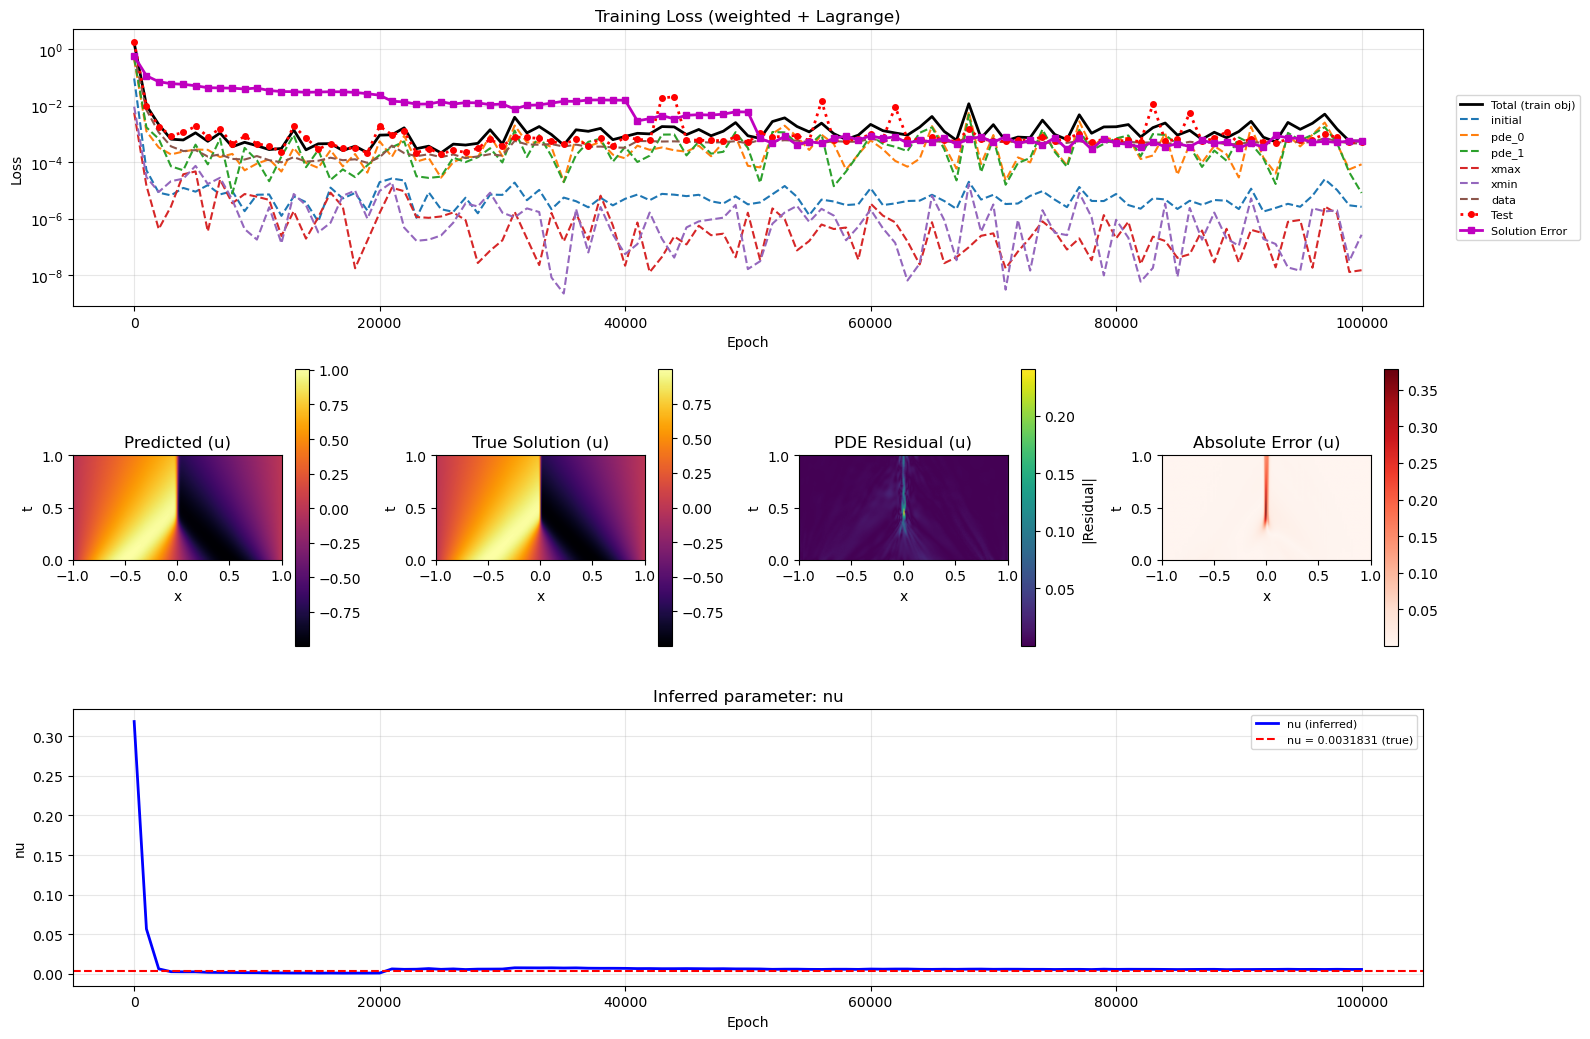

Epoch 0/100000 | Loss: 1.67e+00 | MSE: 1.67e+00 | Terms: [initial: 9.22e-02, pde_0: 4.34e-01, pde_1: 4.90e-01, xmax: 5.63e-03, xmin: 9.20e-03] | Data: [data: 6.42e-01] | Test Loss: 1.82e+00 | Error: 5.71e-01 | Params: [nu: 0.31831] | Time: 0.0s
Epoch 1000/100000 | Loss: 1.01e-02 | MSE: 1.01e-02 | Terms: [initial: 5.16e-05, pde_0: 1.23e-03, pde_1: 1.70e-03, xmax: 1.46e-05, xmin: 2.95e-05] | Data: [data: 7.05e-03] | Test Loss: 9.37e-03 | Error: 1.15e-01 | Params: [nu: 0.0567532] | Time: 10.7s
Epoch 2000/100000 | Loss: 2.15e-03 | MSE: 2.15e-03 | Terms: [initial: 8.27e-06, pde_0: 3.29e-04, pde_1: 6.68e-04, xmax: 4.23e-07, xmin: 8.74e-06] | Data: [data: 1.14e-03] | Test Loss: 1.82e-03 | Error: 7.08e-02 | Params: [nu: 0.00641527] | Time: 12.9s
Epoch 3000/100000 | Loss: 6.51e-04 | MSE: 6.51e-04 | Terms: [initial: 6.63e-06, pde_0: 1.87e-04, pde_1: 7.08e-05, xmax: 2.67e-06, xmin: 2.11e-05] | Data: [data: 3.62e-04] | Test Loss: 8.74e-04 | Error: 6.02e-02 | Params: [nu: 0.00282176] | Time: 15.2s


In [ ]:
trainer = pinns.Trainer(
    network, problem=problem, dataset=dataset,
)

trainer.set_solution(model_burgers.predict)
trainer.set_solution_parameter_problem("nu", nu)

trainer.compile(
    problem = {
        "pde":      {"train": 5000, "test": 10, "weight": 1.0},
        "initial":  {"train": 200,  "test": 10, "weight": 1.0},
        "xmin": {"train": 200,  "test": 10, "weight": 1.0},
        "xmax": {"train": 200,  "test": 10, "weight": 1.0},
    },
    dataset = {
        "data": {"train": 1000, "test": 100, "weight": 1.0},
    },
    fit_problem_parameters=["nu"],
    optimizer=pinns.AdamOptimizer(),
    schedulers=[
        pinns.SchedulerResample(1000),
        pinns.SchedulerCurriculum(
            t_ends=[0.1, 0.2, 0.4, 0.6, 0.8, 1.0],
            epochs_per_stage=10000,
        ),
    ],
    epochs     = 100000,
    print_each = 1000,
)

trainer.train()
